In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("../data/00_df_train.pkl")
df_test = pd.read_pickle("../data/00_df_test.pkl")

In [3]:
print(df.shape)
print(df_test.shape)

(800, 21)
(200, 21)


In [4]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,property,age_years,other_installment_plans,housing,existing_credits_at_bank,job,liable_persons,telephone,foreign_worker,bad
828,<0 DM,36,current credit paid,used car,8335,unknown/no savings,>=7 years,3,male single,none,...,unknown/no property,47,none,free,1,skilled employee/official,1,none,yes,1
997,no account,12,current credit paid,radio/TV,804,<100 DM,>=7 years,4,male single,none,...,car/other property,38,none,own,1,skilled employee/official,1,none,yes,0
148,<0 DM,36,critical/other credit,furniture/equipment,5371,<100 DM,1-4 years,3,male single,guarantor,...,life insurance/building society,28,none,own,2,skilled employee/official,1,none,yes,0
735,0-200 DM,36,bank credit paid,appliances,3990,unknown/no savings,<1 year,3,female married/divorced,none,...,unknown/no property,29,bank,own,1,unemployed/unskilled nonresident,1,none,yes,0
130,0-200 DM,48,current credit paid,new car,8487,unknown/no savings,4-7 years,1,female married/divorced,none,...,car/other property,24,none,own,1,skilled employee/official,1,none,yes,0


In [5]:
df.groupby('bad').size()

bad
0    560
1    240
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 800 entries, 828 to 749
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   checking_account_status   800 non-null    str  
 1   duration_months           800 non-null    int64
 2   credit_history            800 non-null    str  
 3   purpose                   800 non-null    str  
 4   credit_amount             800 non-null    int64
 5   savings_account_bonds     800 non-null    str  
 6   employment_since          800 non-null    str  
 7   installment_rate_percent  800 non-null    int64
 8   personal_status_sex       800 non-null    str  
 9   other_debtors_guarantors  800 non-null    str  
 10  residence_since           800 non-null    int64
 11  property                  800 non-null    str  
 12  age_years                 800 non-null    int64
 13  other_installment_plans   800 non-null    str  
 14  housing                   800 non-null    str  
 15  exi

# correlation

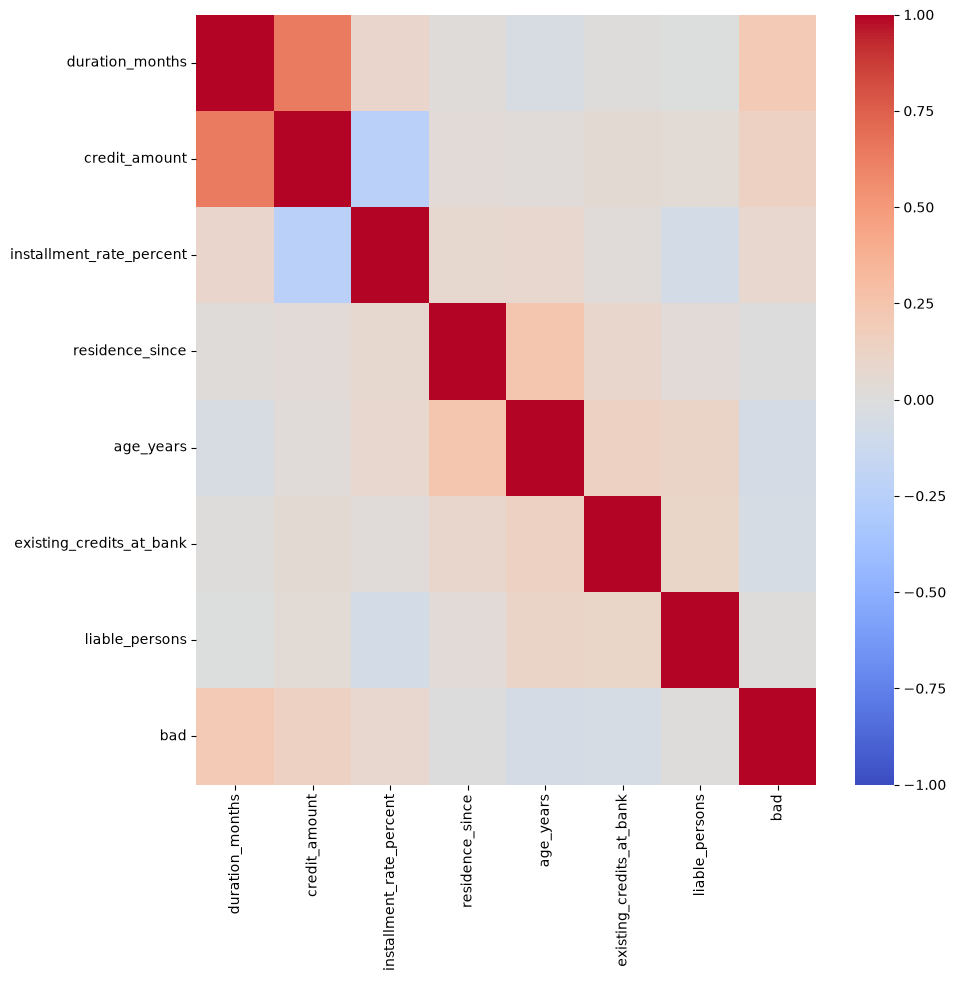

In [7]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 10))
sns.heatmap(
    correlation_matrix,
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

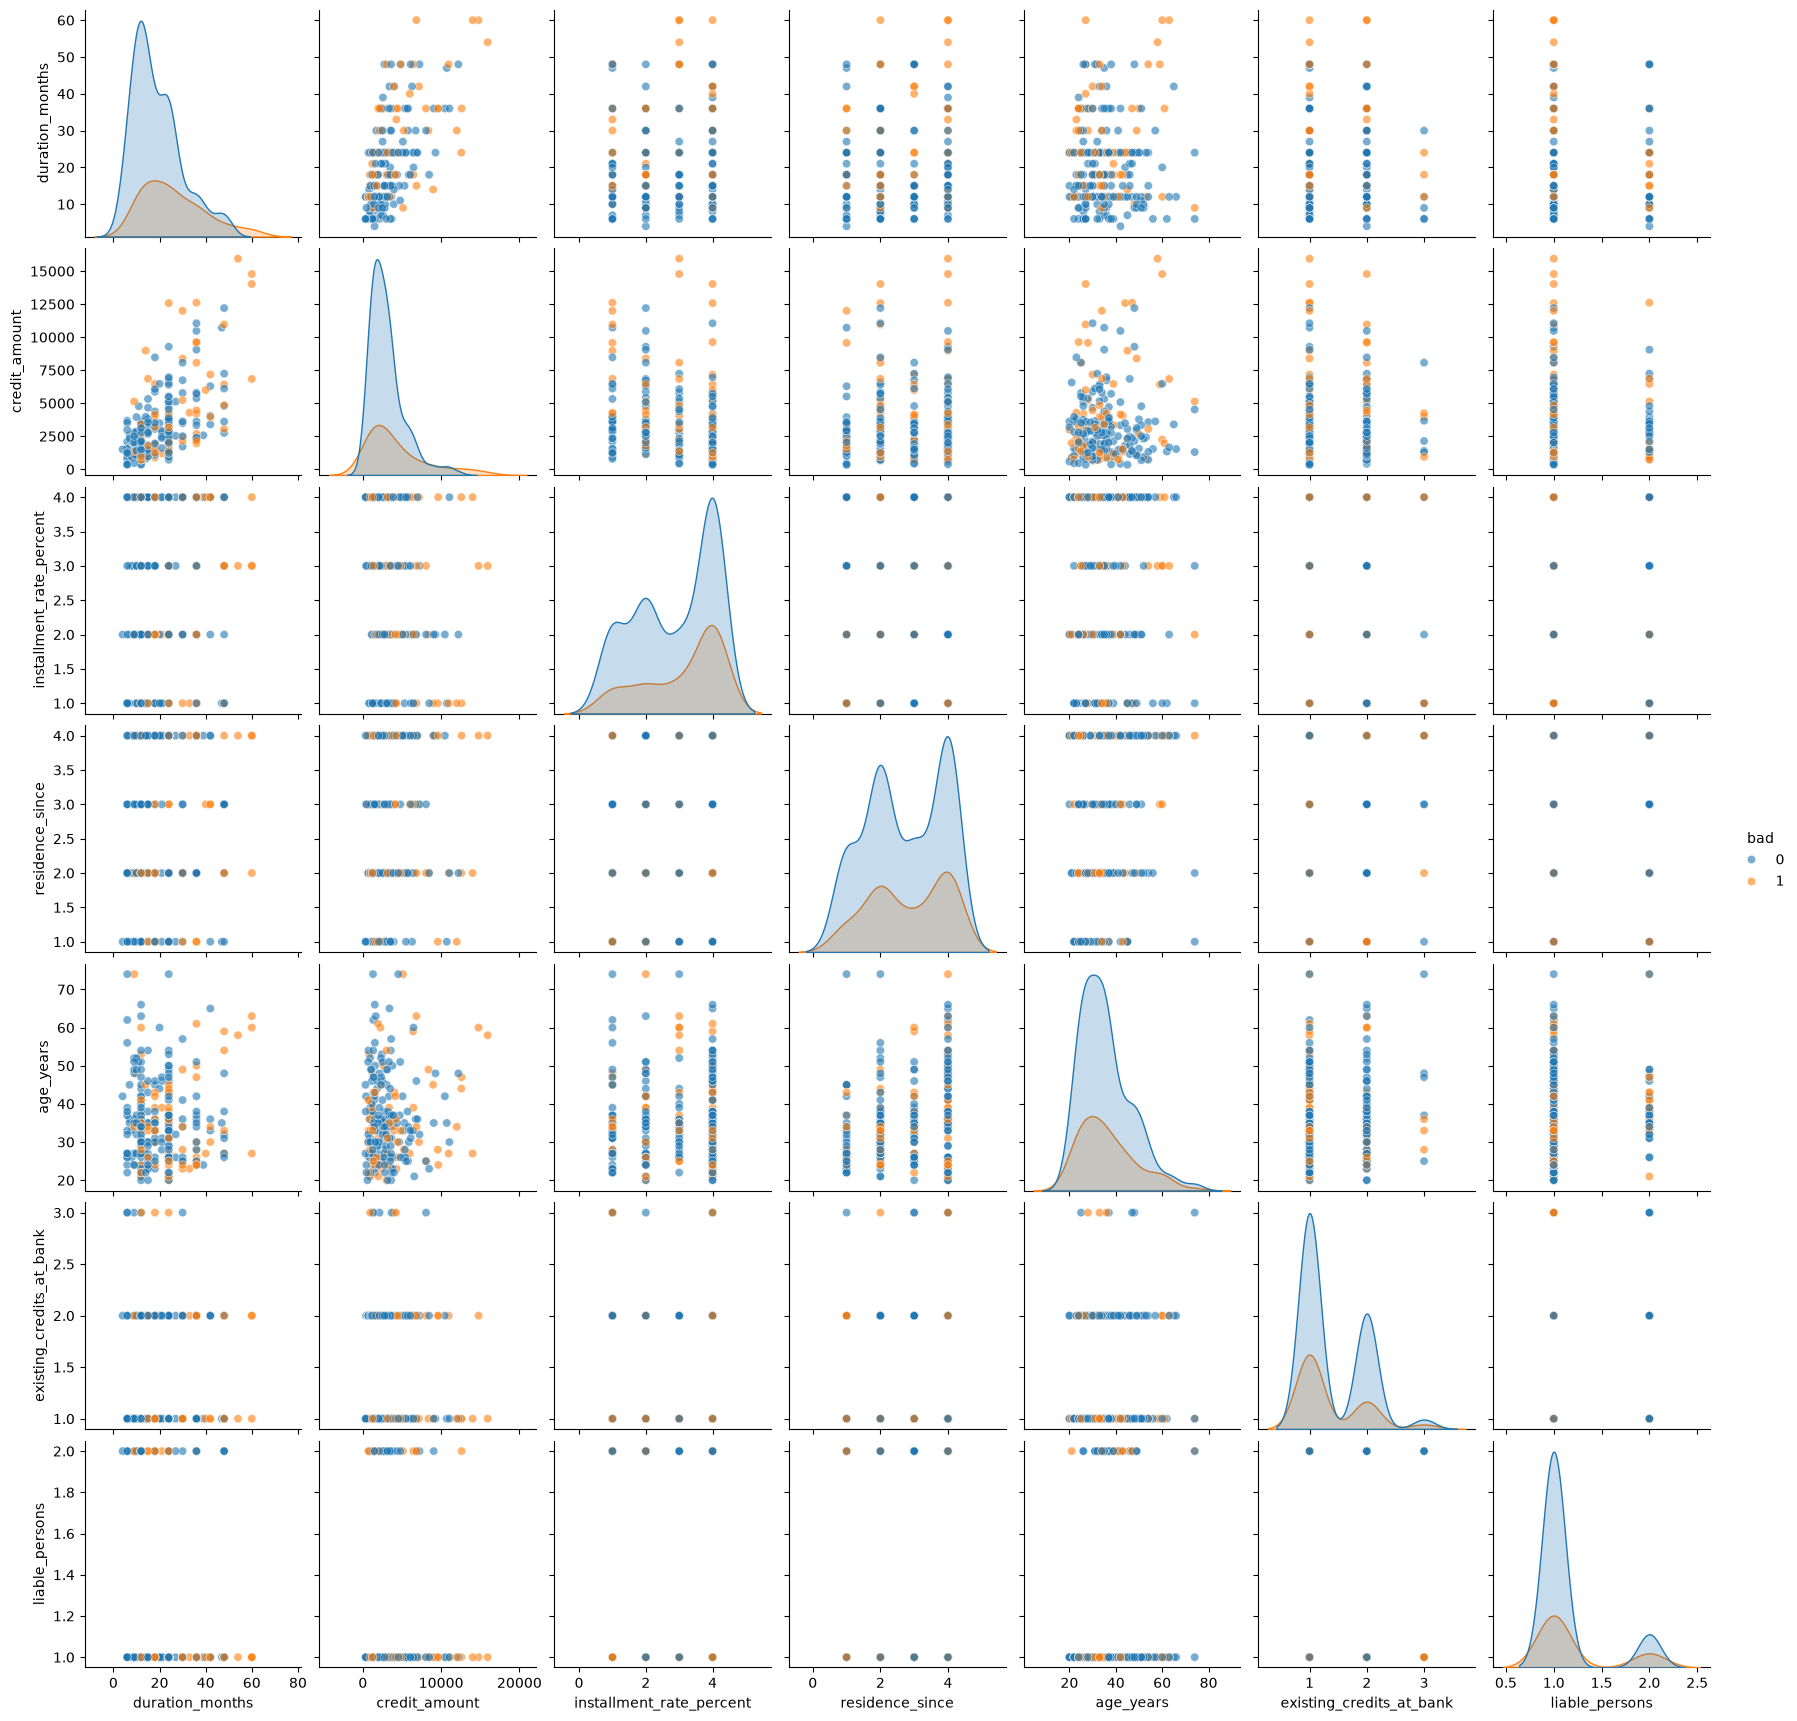

In [8]:
sns.pairplot(
    df.sample(n=250, random_state=42).reset_index(drop=True),
    hue="bad",
    height=2.5,
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)

plt.show()

# domographics

In [9]:
df.columns

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account_bonds', 'employment_since',
       'installment_rate_percent', 'personal_status_sex',
       'other_debtors_guarantors', 'residence_since', 'property', 'age_years',
       'other_installment_plans', 'housing', 'existing_credits_at_bank', 'job',
       'liable_persons', 'telephone', 'foreign_worker', 'bad'],
      dtype='str')

In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_event_num(
    df,
    column_names,
    event_column,
    n_bins=5
):
    """
    Plot histograms and event rates for multiple numerical columns.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    column_names : list
        List of numerical column names to plot.

    event_column : str
        Column containing the event indicator, where 1 represents an event.

    n_bins : int
        Number of bins for each variable.
    """

    n_cols = 3

    if not isinstance(column_names, list):
        raise TypeError("column_names must be a list of column names.")

    required_columns = column_names + [event_column]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"The following columns are missing from the dataframe: "
            f"{missing_columns}"
        )

    if n_bins < 1:
        raise ValueError("n_bins must be at least 1.")

    n_plots = len(column_names)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(7 * n_cols, 5 * n_rows),
        squeeze=False
    )

    axes = axes.flatten()

    for ax1, column in zip(axes, column_names):

        # Remove missing values from the variable and event column
        plot_df = df[[column, event_column]].dropna().copy()

        # Create equally spaced bins
        bin_edges = np.linspace(
            plot_df[column].min(),
            plot_df[column].max(),
            n_bins + 1
        )

        # Handle columns with only one unique value
        if len(np.unique(bin_edges)) < 2:
            ax1.hist(
                plot_df[column],
                bins=1,
                color="skyblue",
                edgecolor="black"
            )
            ax1.set_title(column)
            ax1.set_xlabel(column)
            ax1.set_ylabel("Number of observations")
            continue

        # Assign observations to bins
        plot_df["bin"] = pd.cut(
            plot_df[column],
            bins=bin_edges,
            include_lowest=True
        )

        # Calculate event rate in each bin
        event_rates = (
            plot_df
            .groupby("bin", observed=False)[event_column]
            .mean()
        )

        # Calculate bin centers
        bin_centers = np.array([
            interval.mid for interval in event_rates.index
        ])

        # Histogram
        ax1.hist(
            plot_df[column],
            bins=bin_edges,
            color="skyblue",
            edgecolor="black",
            alpha=0.7
        )

        ax1.set_xlabel(column)
        ax1.set_ylabel("Number of observations")
        ax1.set_title(f"{column}: distribution and event rate")

        # Event-rate line on a secondary y-axis
        ax2 = ax1.twinx()

        ax2.plot(
            bin_centers,
            event_rates.values,
            color="red",
            marker="o",
            linewidth=2,
            label="Event rate"
        )

        ax2.set_ylabel("Event rate")
        ax2.set_ylim(0, 1)
        ax2.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda value, _: f"{value:.0%}")
        )

    # Hide unused subplot axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    fig.tight_layout()
    plt.show()

    return fig, axes


In [11]:
import math
import matplotlib.pyplot as plt


def plot_event_cat(
    df,
    column_names,
    event_column="bad"
):
    n_cols = 3
    n_plots = len(column_names)
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(7 * n_cols, 5 * n_rows),
        squeeze=False
    )

    axes = axes.flatten()

    for ax1, column in zip(axes, column_names):

        plot_df = df[[column, event_column]].copy()

        # Treat missing values as their own category
        plot_df[column] = plot_df[column].fillna("Missing")

        summary = (
            plot_df
            .groupby(column, observed=False)[event_column]
            .agg(
                count="count",
                event_rate="mean"
            )
            .reset_index()
        )

        # Bar chart: number of observations
        ax1.bar(
            summary[column].astype(str),
            summary["count"],
            color="skyblue",
            edgecolor="black",
            alpha=0.7
        )

        ax1.set_xlabel(column)
        ax1.set_ylabel("Number of observations")
        ax1.set_title(f"{column}: distribution and event rate")
        ax1.tick_params(axis="x", rotation=45)

        # Line chart: event rate
        ax2 = ax1.twinx()

        ax2.plot(
            summary[column].astype(str),
            summary["event_rate"],
            color="red",
            marker="o",
            linewidth=2
        )

        ax2.set_ylabel("Event rate")
        ax2.set_ylim(0, 1)
        ax2.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda value, _: f"{value:.0%}")
        )

    # Hide unused plots in the last row
    for ax in axes[len(column_names):]:
        ax.set_visible(False)

    fig.tight_layout()
    plt.show()

    return fig, axes


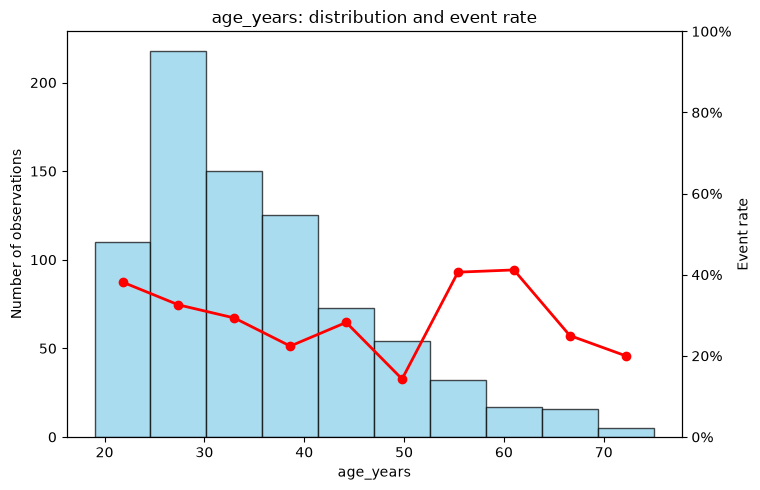

(<Figure size 2100x500 with 4 Axes>,
 array([<Axes: title={'center': 'age_years: distribution and event rate'}, xlabel='age_years', ylabel='Number of observations'>,
        <Axes: >, <Axes: >], dtype=object))

In [12]:
plot_event_num(
    df=df,
    column_names=["age_years"],
    event_column="bad",
    n_bins=10
)

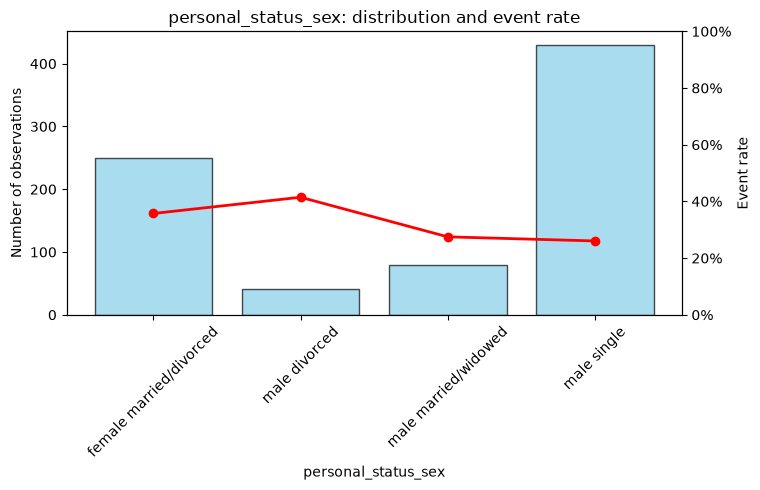

(<Figure size 2100x500 with 4 Axes>,
 array([<Axes: title={'center': 'personal_status_sex: distribution and event rate'}, xlabel='personal_status_sex', ylabel='Number of observations'>,
        <Axes: >, <Axes: >], dtype=object))

In [13]:
plot_event_cat(
    df,
    ['personal_status_sex'],
    event_column="bad"
)

# weight of evidence

In [14]:
df.columns

Index(['checking_account_status', 'duration_months', 'credit_history',
       'purpose', 'credit_amount', 'savings_account_bonds', 'employment_since',
       'installment_rate_percent', 'personal_status_sex',
       'other_debtors_guarantors', 'residence_since', 'property', 'age_years',
       'other_installment_plans', 'housing', 'existing_credits_at_bank', 'job',
       'liable_persons', 'telephone', 'foreign_worker', 'bad'],
      dtype='str')

In [15]:
num_cols = df.select_dtypes(include='number').columns.tolist()
excl = ['bad','age_years']

num_cols = [item for item in num_cols if item not in excl]
num_cols

['duration_months',
 'credit_amount',
 'installment_rate_percent',
 'residence_since',
 'existing_credits_at_bank',
 'liable_persons']

In [16]:
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
excl = ['personal_status_sex']

cat_cols = [item for item in cat_cols if item not in excl]
cat_cols

['checking_account_status',
 'credit_history',
 'purpose',
 'savings_account_bonds',
 'employment_since',
 'other_debtors_guarantors',
 'property',
 'other_installment_plans',
 'housing',
 'job',
 'telephone',
 'foreign_worker']

In [17]:
import toad

combiner = toad.transform.Combiner()

combiner.fit(
    df[num_cols + cat_cols],
    df['bad'],
    method="chi",
    min_samples=0.05
)

In [18]:
X_train_bins = combiner.transform(df[num_cols + cat_cols])
X_test_bins = combiner.transform(df_test[num_cols + cat_cols])

In [19]:
X_train_bins.head()

,duration_months,credit_amount,installment_rate_percent,residence_since,existing_credits_at_bank,liable_persons,checking_account_status,credit_history,purpose,savings_account_bonds,employment_since,other_debtors_guarantors,property,other_installment_plans,housing,job,telephone,foreign_worker
828,6,4,2,3,0,0,3,1,0,2,1,0,3,0,2,0,1,0
997,2,0,3,3,0,0,0,1,0,4,1,0,2,0,0,0,1,0
148,6,4,2,1,1,0,3,0,1,4,2,0,1,0,0,0,1,0
735,6,3,2,1,0,0,2,2,1,2,4,0,3,1,0,1,1,0
130,6,4,0,1,0,0,2,1,1,2,0,0,2,0,0,0,1,0


In [20]:
bin_rules = combiner.export()

print(bin_rules)

{'duration_months': [9, 12, 13, 16, 21, 36], 'credit_amount': [1382, 1778, 2603, 4057], 'installment_rate_percent': [2, 3, 4], 'residence_since': [2, 3, 4], 'existing_credits_at_bank': [2], 'liable_persons': [2], 'checking_account_status': [['no account'], ['>=200 DM'], ['0-200 DM'], ['<0 DM']], 'credit_history': [['critical/other credit'], ['past payment delays', 'current credit paid'], ['bank credit paid', 'no credit/all paid']], 'purpose': [['used car', 'retraining', 'radio/TV'], ['appliances', 'furniture/equipment', 'business', 'other', 'new car', 'repairs', 'education']], 'savings_account_bonds': [['>=1000 DM'], ['500-1000 DM'], ['unknown/no savings'], ['100-500 DM'], ['<100 DM']], 'employment_since': [['4-7 years'], ['>=7 years'], ['1-4 years'], ['unemployed'], ['<1 year']], 'other_debtors_guarantors': [['guarantor', 'none', 'co-applicant']], 'property': [['real estate'], ['life insurance/building society'], ['car/other property'], ['unknown/no property']], 'other_installment_pla

In [21]:
woe_transformer = toad.transform.WOETransformer()

woe_transformer.fit(
    X_train_bins,
    df['bad']
)


In [23]:
X_train_woe = woe_transformer.transform(X_train_bins)
X_test_woe = woe_transformer.transform(X_test_bins)

In [24]:
X_train_woe.head()

,duration_months,credit_amount,installment_rate_percent,residence_since,existing_credits_at_bank,liable_persons,checking_account_status,credit_history,purpose,savings_account_bonds,employment_since,other_debtors_guarantors,property,other_installment_plans,housing,job,telephone,foreign_worker
828,0.713766,0.525398,-0.063573,0.013072,0.078472,-0.011364,0.765060,0.101425,-0.494364,-0.762140,-0.187599,0.0,0.685657,-0.149123,0.470820,-0.048159,0.074108,0.0
997,-0.143101,0.082177,0.178443,0.013072,0.078472,-0.011364,-1.142737,0.101425,-0.494364,0.290162,-0.187599,0.0,0.033661,-0.149123,-0.200495,-0.048159,0.074108,0.0
148,0.713766,0.525398,-0.063573,-0.037517,-0.138150,-0.011364,0.765060,-0.703300,0.258256,0.290162,-0.113329,0.0,-0.005181,-0.149123,-0.200495,-0.048159,0.074108,0.0
735,0.713766,-0.436718,-0.063573,-0.037517,0.078472,-0.011364,0.410580,1.126883,0.258256,-0.762140,0.608406,0.0,0.685657,0.567338,-0.200495,0.233288,0.074108,0.0
130,0.713766,0.525398,-0.274845,-0.037517,0.078472,-0.011364,0.410580,0.101425,0.258256,-0.762140,-0.400846,0.0,0.033661,-0.149123,-0.200495,-0.048159,0.074108,0.0


In [25]:
X_train_woe = X_train_woe.add_suffix("_woe")
X_test_woe = X_test_woe.add_suffix("_woe")

In [26]:
vars_woe = X_train_woe.columns.tolist()

In [27]:
print(X_train_woe.shape)
print(X_test_woe.shape)

(800, 18)
(200, 18)


In [28]:
print(df.shape)
print(df_test.shape)

(800, 21)
(200, 21)


In [29]:
df = pd.concat(
    [df, X_train_woe],
    axis=1
)

df_test = pd.concat(
    [df_test, X_test_woe],
    axis=1
)


In [30]:
print(df.shape)
print(df_test.shape)

(800, 39)
(200, 39)


In [31]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,purpose_woe,savings_account_bonds_woe,employment_since_woe,other_debtors_guarantors_woe,property_woe,other_installment_plans_woe,housing_woe,job_woe,telephone_woe,foreign_worker_woe
828,<0 DM,36,current credit paid,used car,8335,unknown/no savings,>=7 years,3,male single,none,...,-0.494364,-0.762140,-0.187599,0.0,0.685657,-0.149123,0.470820,-0.048159,0.074108,0.0
997,no account,12,current credit paid,radio/TV,804,<100 DM,>=7 years,4,male single,none,...,-0.494364,0.290162,-0.187599,0.0,0.033661,-0.149123,-0.200495,-0.048159,0.074108,0.0
148,<0 DM,36,critical/other credit,furniture/equipment,5371,<100 DM,1-4 years,3,male single,guarantor,...,0.258256,0.290162,-0.113329,0.0,-0.005181,-0.149123,-0.200495,-0.048159,0.074108,0.0
735,0-200 DM,36,bank credit paid,appliances,3990,unknown/no savings,<1 year,3,female married/divorced,none,...,0.258256,-0.762140,0.608406,0.0,0.685657,0.567338,-0.200495,0.233288,0.074108,0.0
130,0-200 DM,48,current credit paid,new car,8487,unknown/no savings,4-7 years,1,female married/divorced,none,...,0.258256,-0.762140,-0.400846,0.0,0.033661,-0.149123,-0.200495,-0.048159,0.074108,0.0


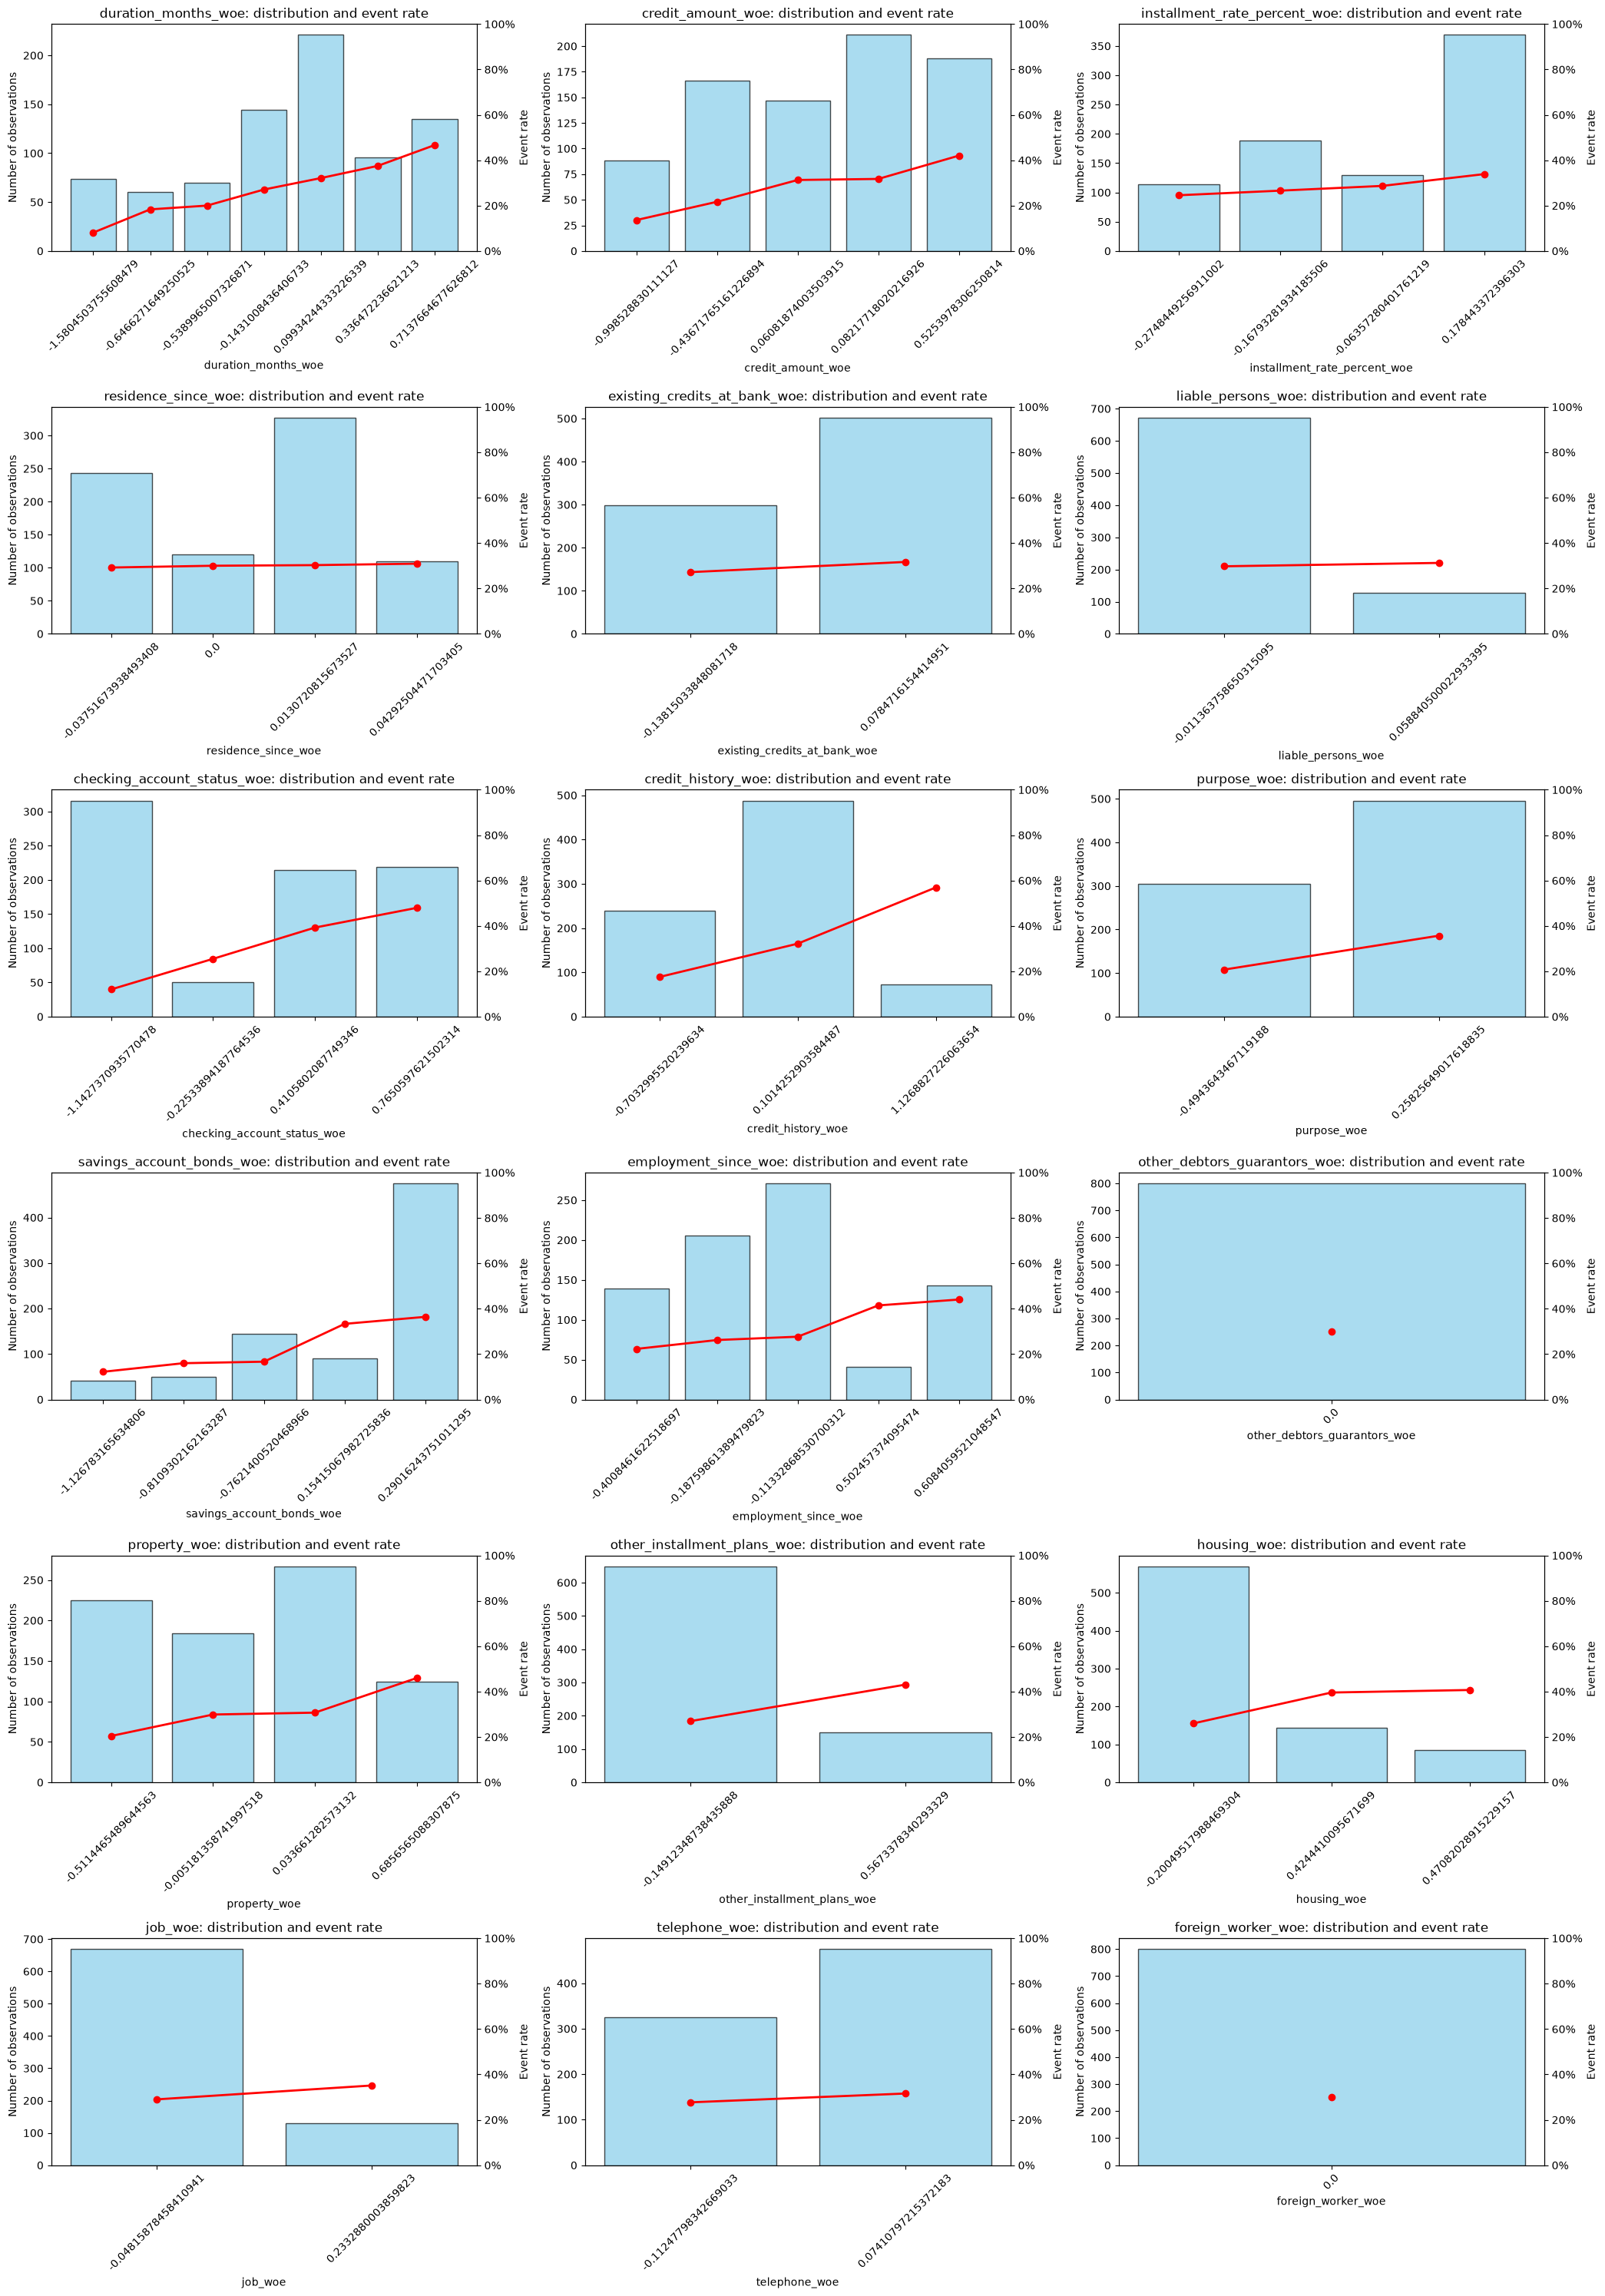

(<Figure size 2100x3000 with 36 Axes>,
 array([<Axes: title={'center': 'duration_months_woe: distribution and event rate'}, xlabel='duration_months_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'credit_amount_woe: distribution and event rate'}, xlabel='credit_amount_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'installment_rate_percent_woe: distribution and event rate'}, xlabel='installment_rate_percent_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'residence_since_woe: distribution and event rate'}, xlabel='residence_since_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'existing_credits_at_bank_woe: distribution and event rate'}, xlabel='existing_credits_at_bank_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'liable_persons_woe: distribution and event rate'}, xlabel='liable_persons_woe', ylabel='Number of observations'>,
        <Axes: title={'center': 'chec

In [32]:
plot_event_cat(
    pd.concat([df[vars_woe].astype(object),df['bad']], axis=1),
    vars_woe,
    event_column="bad"
)

## save woe data

In [33]:
# save dataframes to data

# save var lists

In [120]:
feat_names = {}

In [121]:
feat_names['raw'] = [num_cols + cat_cols]
feat_names['woe'] = vars_woe

In [122]:
feat_names

{'raw': [['duration_months',
   'credit_amount',
   'installment_rate_percent',
   'residence_since',
   'existing_credits_at_bank',
   'liable_persons',
   'checking_account_status',
   'credit_history',
   'purpose',
   'savings_account_bonds',
   'employment_since',
   'other_debtors_guarantors',
   'property',
   'other_installment_plans',
   'housing',
   'job',
   'telephone',
   'foreign_worker']],
 'woe': ['duration_months_woe',
  'credit_amount_woe',
  'installment_rate_percent_woe',
  'residence_since_woe',
  'existing_credits_at_bank_woe',
  'liable_persons_woe',
  'checking_account_status_woe',
  'credit_history_woe',
  'purpose_woe',
  'savings_account_bonds_woe',
  'employment_since_woe',
  'other_debtors_guarantors_woe',
  'property_woe',
  'other_installment_plans_woe',
  'housing_woe',
  'job_woe',
  'telephone_woe',
  'foreign_worker_woe']}

In [ ]:
# save to data

# univariate variable importance

In [ ]:
# redo this but with woes

In [40]:
import numpy as np
import pandas as pd
import statsmodels.api as sm


def calculate_wald_statistics(
    df,
    column_names,
    event_column
):
    """
    Calculate one Wald statistic per input variable.

    Numeric variables are tested directly.
    Categorical variables are one-hot encoded internally and tested jointly.
    """

    required_columns = column_names + [event_column]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"The following columns are missing: {missing_columns}"
        )

    wald_results = []

    for column in column_names:

        model_df = df[[column, event_column]].dropna()

        # Convert categorical columns to dummy variables
        X = pd.get_dummies(
            model_df[[column]],
            drop_first=True,
            dtype=float
        )

        y = model_df[event_column].astype(float)

        # Skip variables with no variation
        if X.shape[1] == 0:
            continue

        X = sm.add_constant(X)

        try:
            model = sm.Logit(y, X).fit(disp=False)

            predictor_columns = list(X.columns)
            predictor_columns.remove("const")

            # Position of predictor columns in model.params
            predictor_indices = [
                predictor_columns.index(col) + 1
                for col in predictor_columns
            ]

            # Constraint matrix for a joint Wald test
            constraint_matrix = np.zeros(
                (len(predictor_indices), len(model.params))
            )

            for row, index in enumerate(predictor_indices):
                constraint_matrix[row, index] = 1

            # Joint Wald statistic for the variable
            wald_test = model.wald_test(
                constraint_matrix,
                scalar=True
            )

            wald_statistic = float(wald_test.statistic)

            wald_results.append({
                "var": column,
                "wald": wald_statistic
            })

        except Exception as error:
            print(f"Could not fit model for '{column}': {error}")

    walds = (
        pd.DataFrame(wald_results)
        .sort_values(by="wald", ascending=False)
        .reset_index(drop=True)
    )

    return walds


In [41]:
df.info()

<class 'pandas.DataFrame'>
Index: 800 entries, 828 to 749
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   checking_account_status   800 non-null    str  
 1   duration_months           800 non-null    int64
 2   credit_history            800 non-null    str  
 3   purpose                   800 non-null    str  
 4   credit_amount             800 non-null    int64
 5   savings_account_bonds     800 non-null    str  
 6   employment_since          800 non-null    str  
 7   installment_rate_percent  800 non-null    int64
 8   personal_status_sex       800 non-null    str  
 9   other_debtors_guarantors  800 non-null    str  
 10  residence_since           800 non-null    int64
 11  property                  800 non-null    str  
 12  age_years                 800 non-null    int64
 13  other_installment_plans   800 non-null    str  
 14  housing                   800 non-null    str  
 15  exi

In [42]:
column_names = [
    "checking_account_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account_bonds",
    "employment_since",
    "installment_rate_percent",
    "other_debtors_guarantors",
    "residence_since",
    "property",
    "other_installment_plans",
    "housing",
    "existing_credits_at_bank",
    "job",
    "liable_persons",
    "telephone",
    "foreign_worker"
]

In [43]:
walds = calculate_wald_statistics(
    df=df,
    column_names=column_names,
    event_column="bad"
)

In [44]:
walds

,var,wald
0,checking_account_status,81.374162
1,credit_history,40.627883
2,duration_months,32.161961
3,savings_account_bonds,30.802473
4,purpose,24.380446
5,property,24.013138
6,employment_since,21.466149
7,other_installment_plans,15.866271
8,housing,15.173953
9,credit_amount,14.739425


# correlation by importance

In [90]:
correlation_matrix = df[walds['var'].tolist()].corr(numeric_only=True)

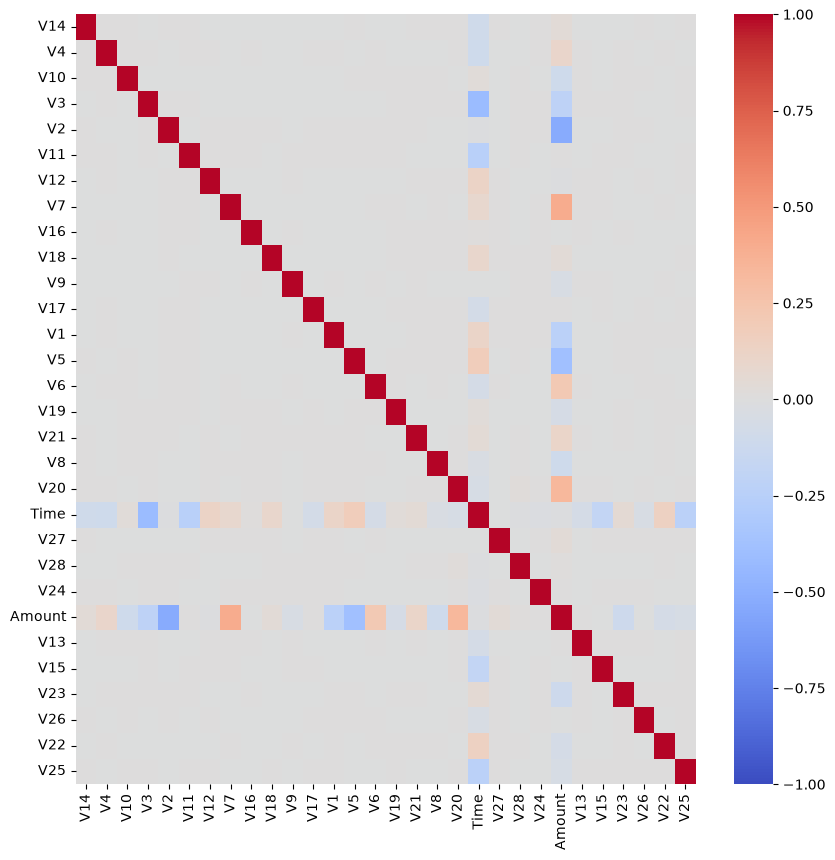

In [91]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    correlation_matrix,
    # annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.show()

In [92]:
correlation_matrix.head()

,V14,V4,V10,V3,V2,V11,V12,V7,V16,V18,...,V27,V28,V24,Amount,V13,V15,V23,V26,V22,V25
V14,1.000000,0.001400,0.000148,-0.002869,0.001936,0.002802,-0.002292,-0.002143,-0.003194,-0.000430,...,0.003611,-0.001011,0.000056,0.032659,-0.001923,-0.000094,-0.000048,0.000358,-0.002131,0.001204
V4,0.001400,1.000000,0.001073,0.000563,-0.001218,0.000027,0.000110,-0.000022,0.001098,-0.000295,...,-0.001701,-0.005669,0.001635,0.099970,0.000105,-0.000139,0.000665,-0.000138,0.001295,-0.001727
V10,0.000148,0.001073,1.000000,-0.001276,-0.001682,-0.000254,-0.000697,-0.001023,-0.000416,-0.000427,...,-0.002690,0.004293,-0.001581,-0.102396,0.000493,-0.000313,0.000846,0.000800,-0.000602,0.001258
V3,-0.002869,0.000563,-0.001276,1.000000,0.002215,0.000472,-0.000218,-0.004195,-0.002985,-0.000464,...,-0.001733,0.007445,0.000214,-0.211310,0.000426,0.000875,0.000476,-0.000229,-0.001957,0.001974
V2,0.001936,-0.001218,-0.001682,0.002215,1.000000,-0.001694,0.000621,0.003261,0.001515,0.000433,...,-0.000879,0.005784,0.002428,-0.530143,-0.000907,-0.000647,0.000549,0.000960,-0.000011,-0.000463


In [93]:
corr_tmp = correlation_matrix.copy()

In [94]:
corr_ind = pd.DataFrame(columns = ['var','corr','corr ind'])

thresh = .3

for i in corr_tmp.columns:
    # print(i)

    # mx = corr_tmp[i].max()
    mx = corr_tmp[i].drop(index=i).max()
    mi = corr_tmp[i].drop(index=i).min()

    if abs(mx) > abs(mi):
        res = mx
    else:
        res = mi

    

    # print(res)

    if abs(res) > thresh:
        indy = True
    else:
        indy = False

    
    new_row = pd.DataFrame([{
    "var": i,
    'corr': res,
    "corr ind": indy
    }])

    corr_ind = pd.concat([corr_ind, new_row], ignore_index=True)

    # break

In [95]:
walds = pd.merge(walds, corr_ind, on="var", how="left")

In [96]:
walds

,var,wald,corr,corr ind
0,V14,1951.546659,-0.099085,False
1,V4,1703.435651,-0.106422,False
2,V10,1617.13706,-0.102396,False
3,V3,1541.035483,-0.420856,True
4,V2,1478.19184,-0.530143,True
5,V11,1453.420843,-0.247649,False
6,V12,1403.316979,0.123089,False
7,V7,1391.898556,0.398941,True
8,V16,1349.501453,0.012829,False
9,V18,1301.444612,0.089691,False


# save wald table

In [97]:
walds.to_pickle("../data/walds.pkl")